# Social Media Impact on Teen Mental Health

From: https://www.kaggle.com/datasets/algozee/teenager-menthal-healy?select=Teen_Mental_Health_Dataset.csv

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
mental_health = pd.read_csv("Teen_Mental_Health_Dataset.csv")

## Data Set
### Missing Data

In [4]:
print(mental_health.isna().sum(),"\n")
print(mental_health.duplicated().sum())

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64 

0


Der Datensatz weist keine Duplikate und fehlende Werte auf, was auf eine guten Datenqualität hinweist.

### Data Inspection

In [5]:
mental_health.head(15)

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0


In [6]:
mental_health.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


In [7]:
mental_health.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


## EDA


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

| Attribut                      | Skalenniveau  | Datentyp
|-------------------------------|---------------|----------------
| age                           | Verhältnis    | numerisch
| gender                        | Nominal       | kategorisch
| daily_social_media_hours      | Verhältnis    | numerisch
| platform_usage                | Nominal       | kategorisch
| sleep_hours                   | Verhältnis    | numerisch
| screen_time_before_sleep      | Verhältnis    | numerisch
| academic_performance          | Verhältnis    | numerisch
| physical_activity             | Verhältnis    | numerisch
| social_interaction_level      | Ordinal       | kategorisch
| stress_level                  | Ordinal       | numerisch
| anxiety_level                 | Ordinal       | numerisch
| addiction_level               | Ordinal       | numerisch
| depression_label              | Nominal       | kategorisch

### Univariate Analysis

#### Target Variable

In [9]:
mental_health["depression_label"].value_counts()

depression_label
0    1169
1      31
Name: count, dtype: int64

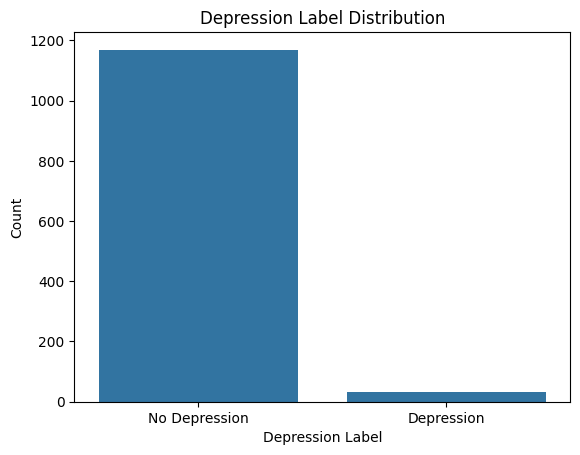

In [10]:
sns.countplot(data=mental_health, x="depression_label")
plt.title("Depression Label Distribution")
plt.xlabel("Depression Label")
plt.ylabel("Count")
plt.xticks([0,1], ["No Depression", "Depression"])
plt.show()

Hier ein deutliche Unausgeglichenheit vor, wobei "No Depression" in der klaren Mehrheit liegt. Dies muss mein beim Trainieren von Modellen berücksichtigen, sowie die richtigen Evaluationsmetriken wählen.

#### Nummerisch

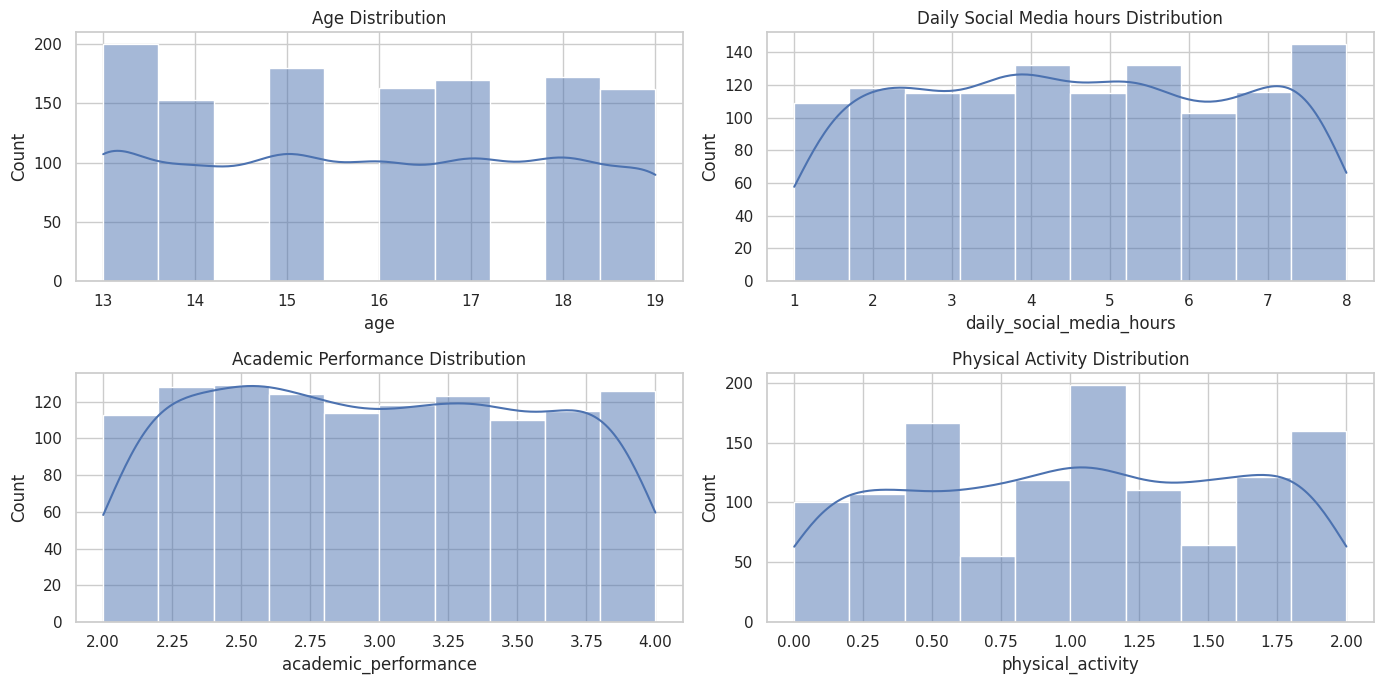

In [11]:
sns.set_theme(style="whitegrid")


fig, axes = plt.subplots(2, 2, figsize=(14, 7))

columns = ["age", "daily_social_media_hours", "academic_performance", "physical_activity"]

titles = ["Age Distribution", "Daily Social Media hours Distribution", "Academic Performance Distribution" , "Physical Activity Distribution"]

for ax, col, title in zip(axes.flatten(), columns, titles):
    sns.histplot(mental_health[col], bins=10, kde=True, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    
plt.tight_layout()
plt.show()

Bei Age Distribution, Daily Social Media hours Distribution und Academic Performance Distribution kann man eine gleichmäßige Verteilung erkennen. Dabei gibt es keine Ausreißer in den kategorien.
Durch die gleichmäßige Verteilung heißt es auch, dass bei Daily Social Media hours die Jugendlichen sehr lange am Handy hängen (bis zu 8 Stunden), wodurch die Länge der sportlichen Aktivitäten runter geht.

##### Sleep

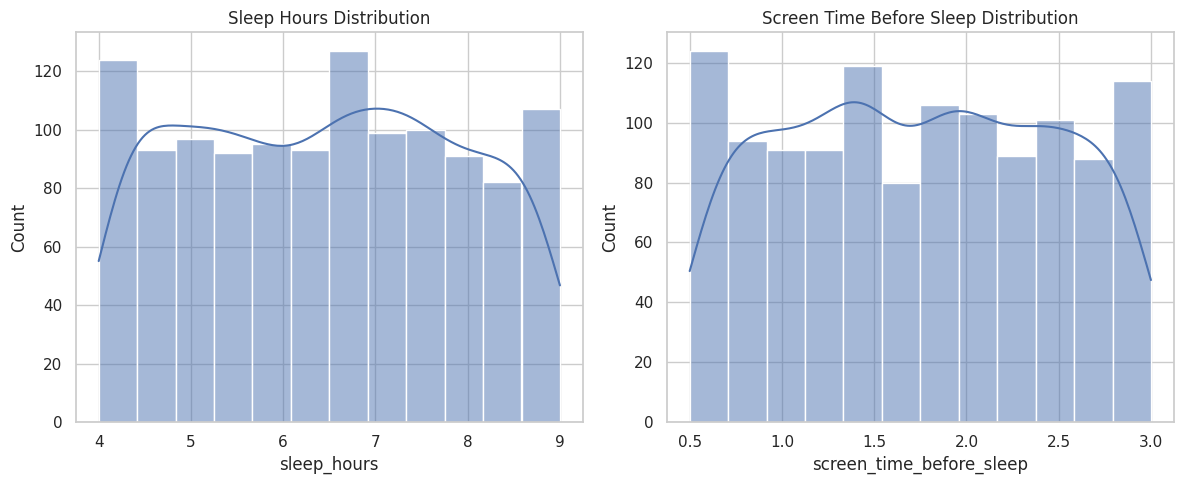

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

columns = ["sleep_hours", "screen_time_before_sleep"]

titles = ["Sleep Hours Distribution", "Screen Time Before Sleep Distribution"]

for ax, col, title in zip(axes.flatten(), columns, titles):
    sns.histplot(mental_health[col], bins=12, kde=True, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    
plt.tight_layout()
plt.show()

In der Kategorie Sleep kann man bei den beiden Features ein "relative" Gleichverteilung erkennen. Was aber erschrenkend ist, ist die Tatsache, dass etwas mehr als 120 Jugendliche nur 4 Stunden Schlaf haben.

##### Stress / Anxiety / Addiction

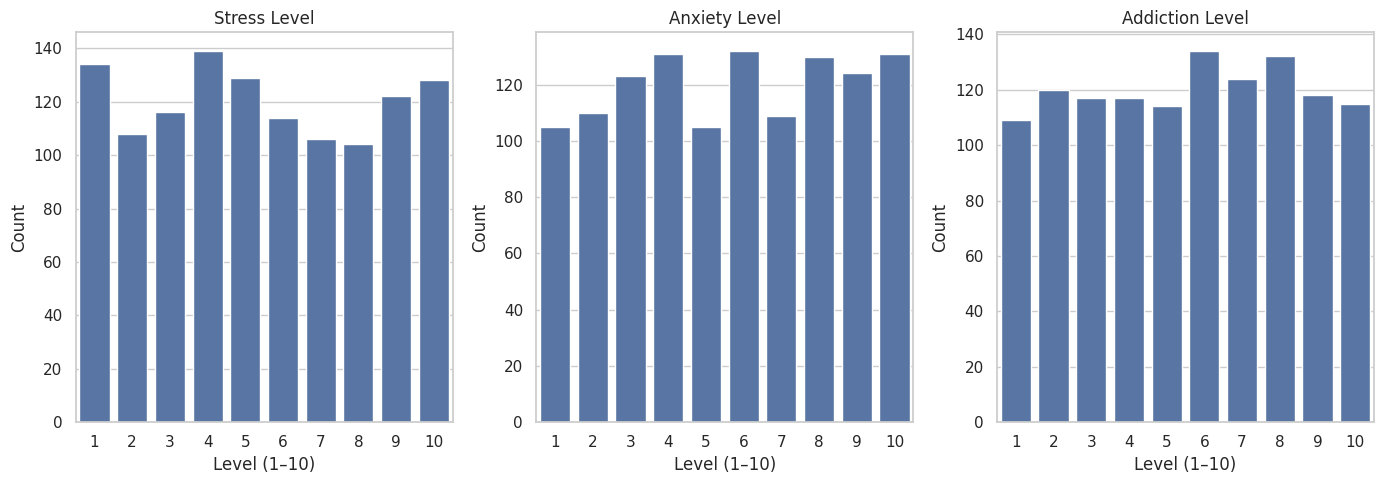

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

columns = ["stress_level", "anxiety_level", "addiction_level"]
titles = ["Stress Level", "Anxiety Level", "Addiction Level"]

for ax, col, title in zip(axes, columns, titles):
    sns.countplot(data=mental_health, x=col, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Level (1–10)")
    ax.set_ylabel("Count")
    ax.set_xticks(range(0, 10))
    ax.set_xticklabels(range(1, 11))

plt.tight_layout()
plt.show()

Hier kann man ebenfalls eine "relative" Gleichverteilung in den Kategorien erkennen.

#### Kategorische Attribute

##### Gender

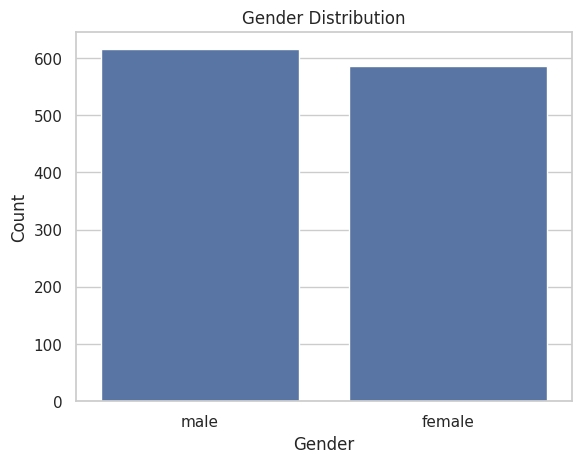

In [14]:
sns.countplot(data=mental_health, x=mental_health["gender"])
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

##### platform_usage

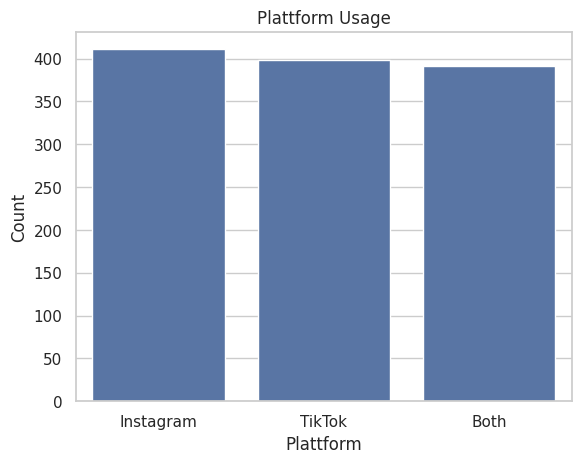

In [15]:
sns.countplot(data=mental_health, x=mental_health["platform_usage"])
plt.title("Plattform Usage")
plt.xlabel("Plattform")
plt.ylabel("Count")
plt.show()

##### social_interaction_level

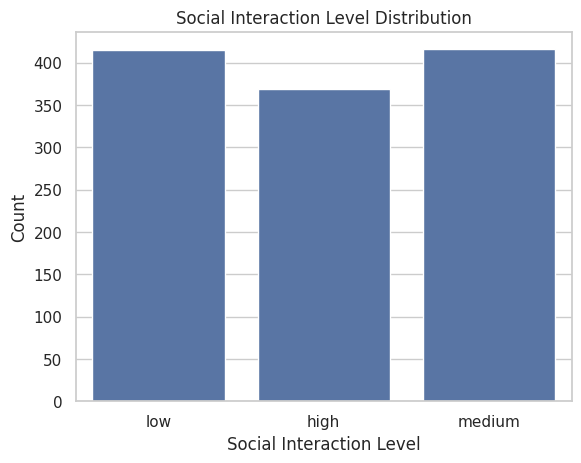

In [16]:
sns.countplot(data=mental_health, x=mental_health["social_interaction_level"])
plt.title("Social Interaction Level Distribution")
plt.xlabel("Social Interaction Level")
plt.ylabel("Count")
plt.show()

### Bivariate Analysis

#### Every feature vs target feature

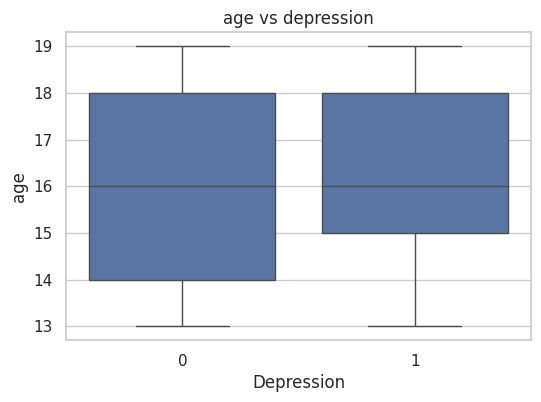

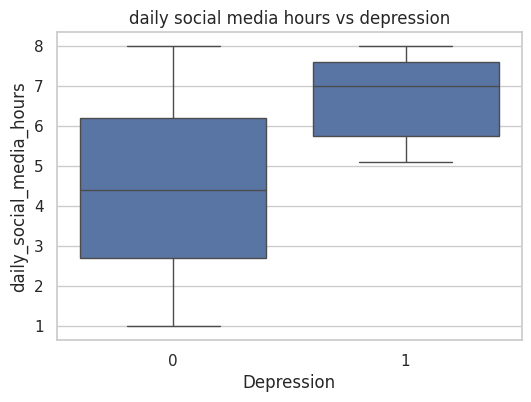

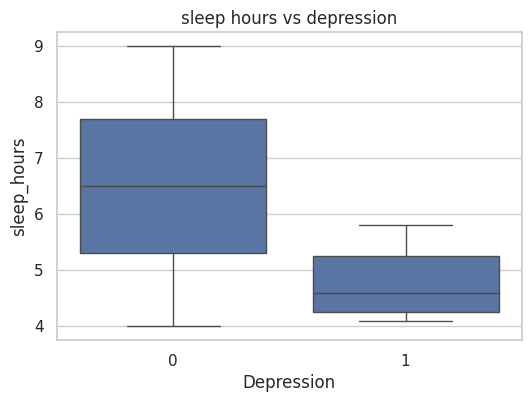

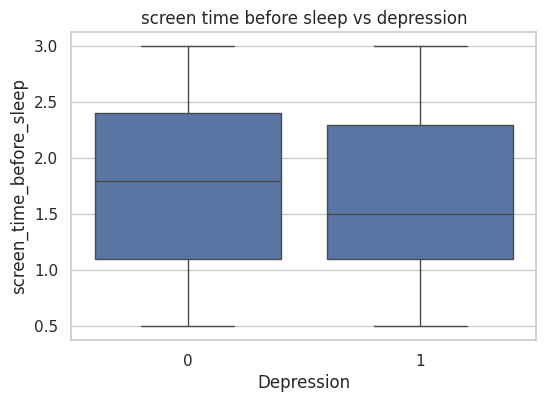

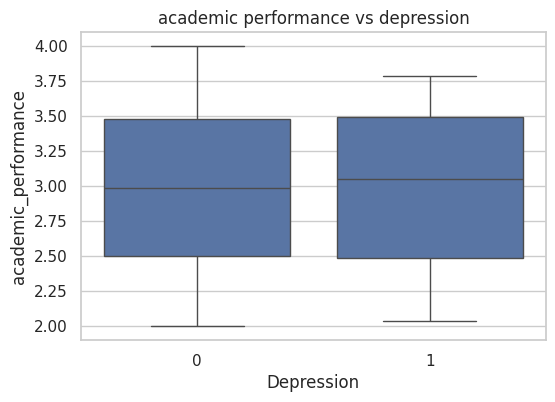

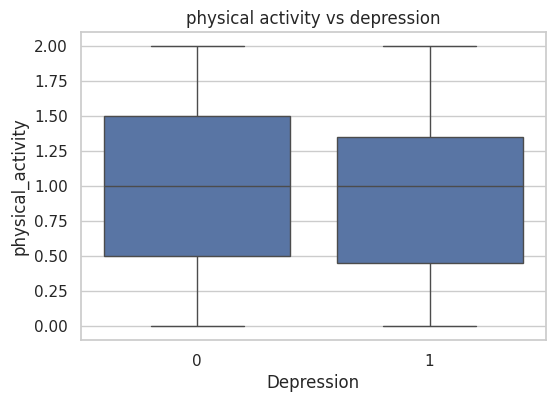

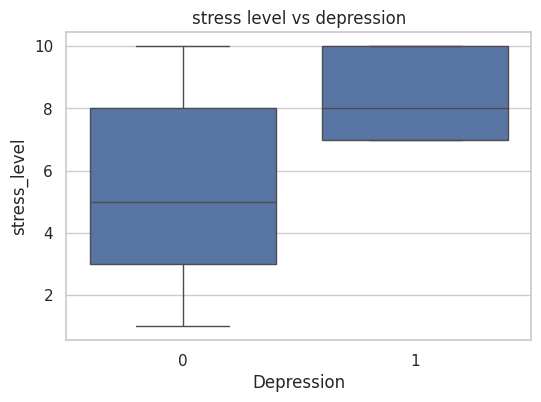

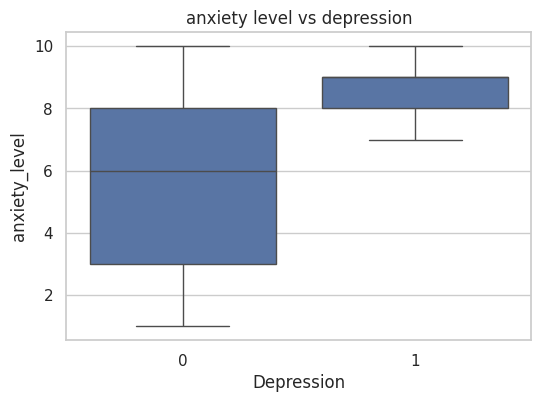

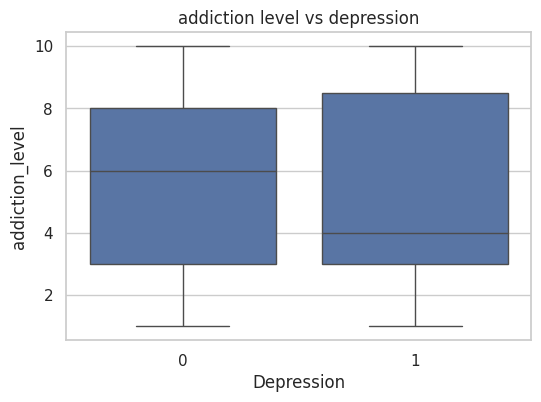

In [17]:
features = ["age", "daily_social_media_hours", "sleep_hours", "screen_time_before_sleep", "academic_performance", "physical_activity", "stress_level", "anxiety_level", "addiction_level"]

for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=mental_health, x="depression_label", y=feature)
    plt.title(f"{feature.replace("_"," ")} vs depression")
    plt.xlabel("Depression")
    plt.ylabel(f"{feature}")
    plt.show()
    

Aus den Grafen kann man 2 unterschiedliche Beobachtungen tätigen.
1. age vs depression, screen time befor sleep vs depression, academic preformance vs depression, physical activity vs depression und addiction level vs depression zeigen wie die Klassen eine starke Überlappung in den Gruppen (No Depreesion und Depression) haben. Die Überlappung weist darauf hin, wie die Klassen kein/kaum ein Zusammenhand mit Depressionen haben.

2. daily social media hours vs depression, sleep hours vs depression, anxiety level vs depression, stress level vs depression zeigen eine symmetrische Verteilung um den Median in der Gruppe 0 (No Depression), während in Gruppe 1 die Verteilung stark nach oben bzw nach unten ist

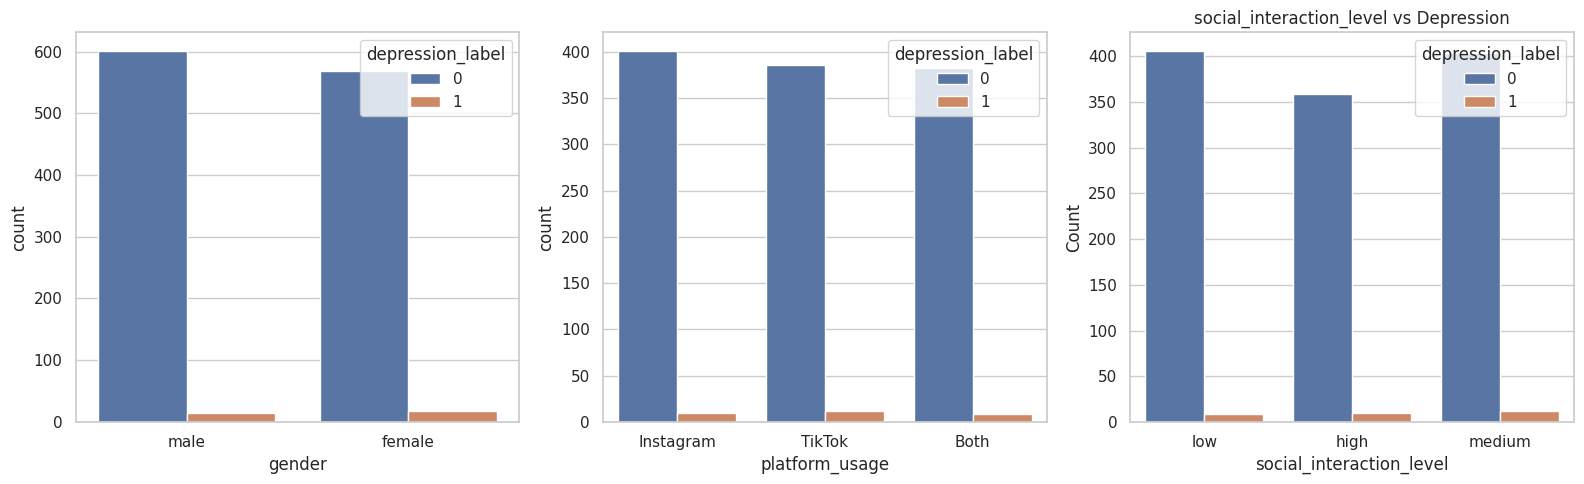

In [18]:
fig ,axes = plt.subplots(1, 3, figsize=(16,5))

features = ["gender", "platform_usage", "social_interaction_level"]

titles = ["Gender", "Platform Usage", "Social Interaction Level"]

for ax, feature, title in zip(axes.flatten(), features, titles):
    sns.countplot(data=mental_health, x=feature, hue="depression_label", ax=ax)
    plt.title(f"{feature} vs Depression")
    plt.xlabel(f"{feature}")
    plt.ylabel("Count")
    
plt.tight_layout()
plt.show()

#### sleep_hours vs. daily_social_media_hours

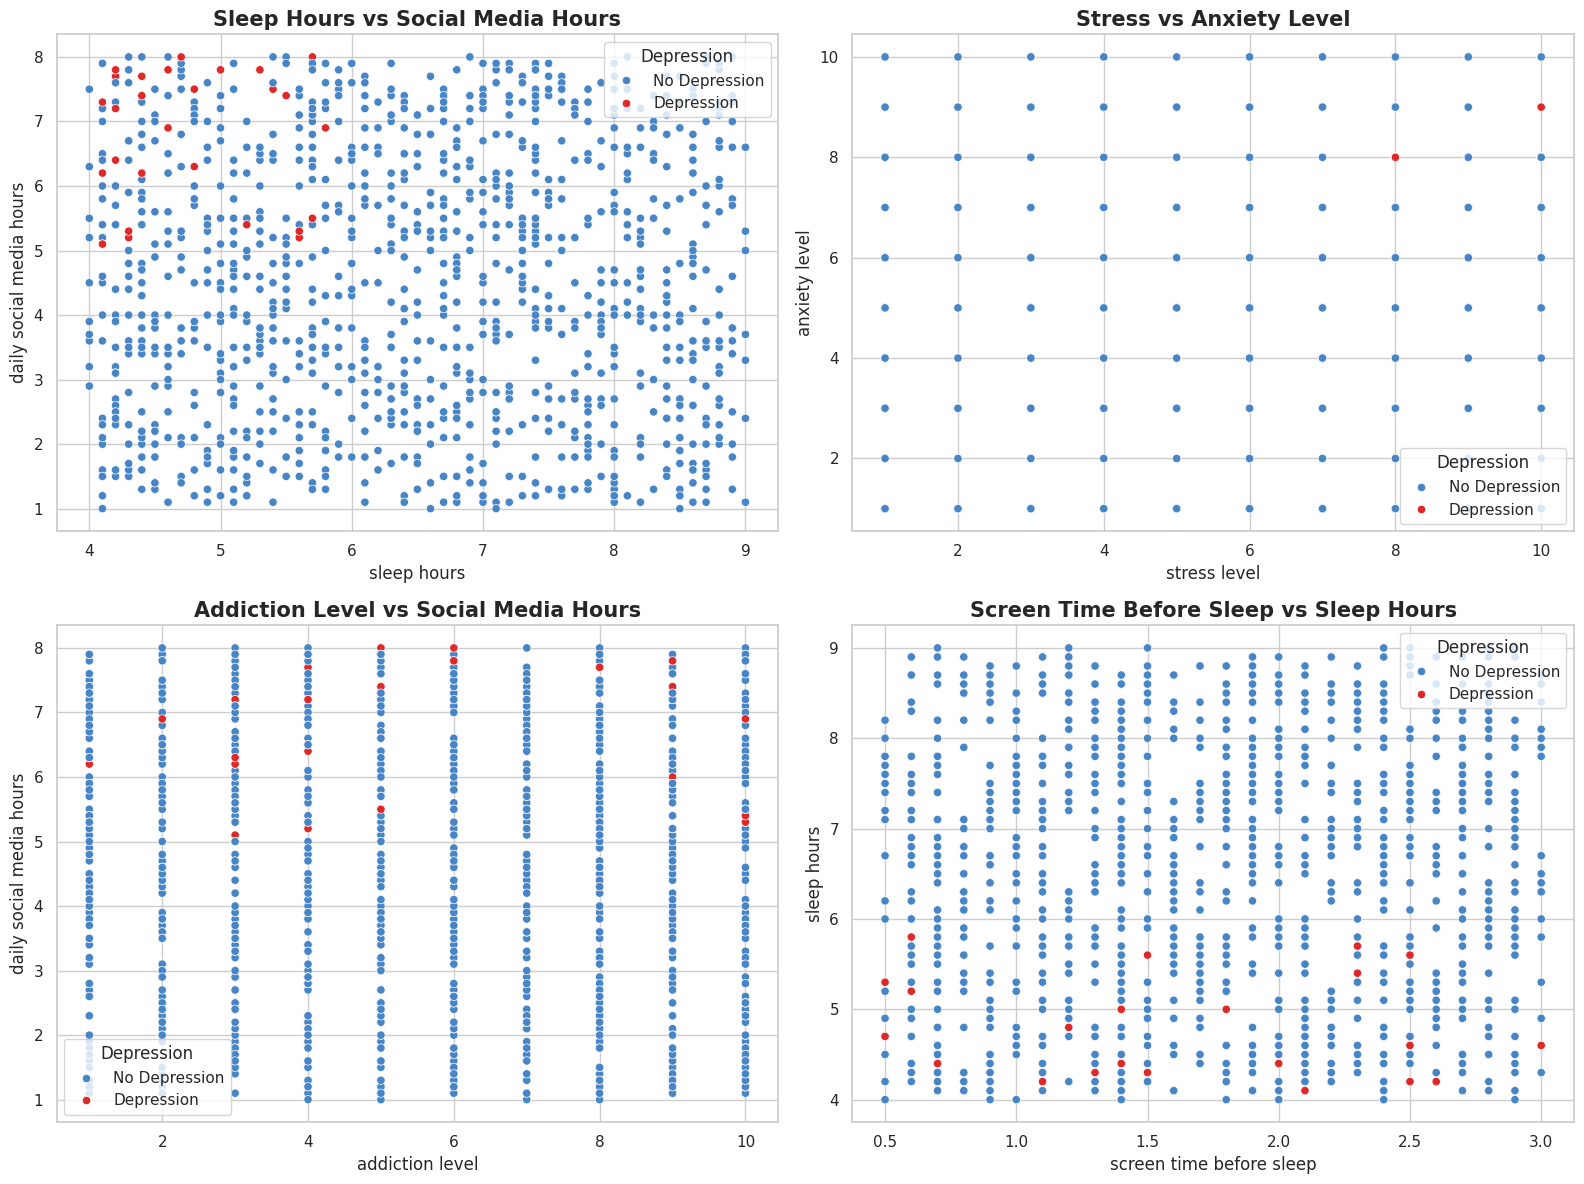

In [19]:
fig ,axes = plt.subplots(2, 2, figsize=(16,12))

features_x = ["sleep_hours", "stress_level", "addiction_level", "screen_time_before_sleep"]


features_y = ["daily_social_media_hours", "anxiety_level", "daily_social_media_hours", "sleep_hours"]

titles = ["Sleep Hours vs Social Media Hours", "Stress vs Anxiety Level",
          "Addiction Level vs Social Media Hours", "Screen Time Before Sleep vs Sleep Hours"]

palette = {0: "#4785C7", 1: "#DF2828"} 

for ax, feature_x, feature_y, title in zip(axes.flatten(), features_x, features_y, titles):
    sns.scatterplot(data=mental_health, x=feature_x, y=feature_y, hue="depression_label", ax=ax, palette=palette)
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_xlabel(feature_x.replace("_"," "))
    ax.set_ylabel(feature_y.replace("_"," "))
    handles, _ = ax.get_legend_handles_labels()
    ax.legend(handles=handles,title="Depression", labels=["No Depression", "Depression"])
    
plt.tight_layout()
plt.show()

### Multivariate Analysis

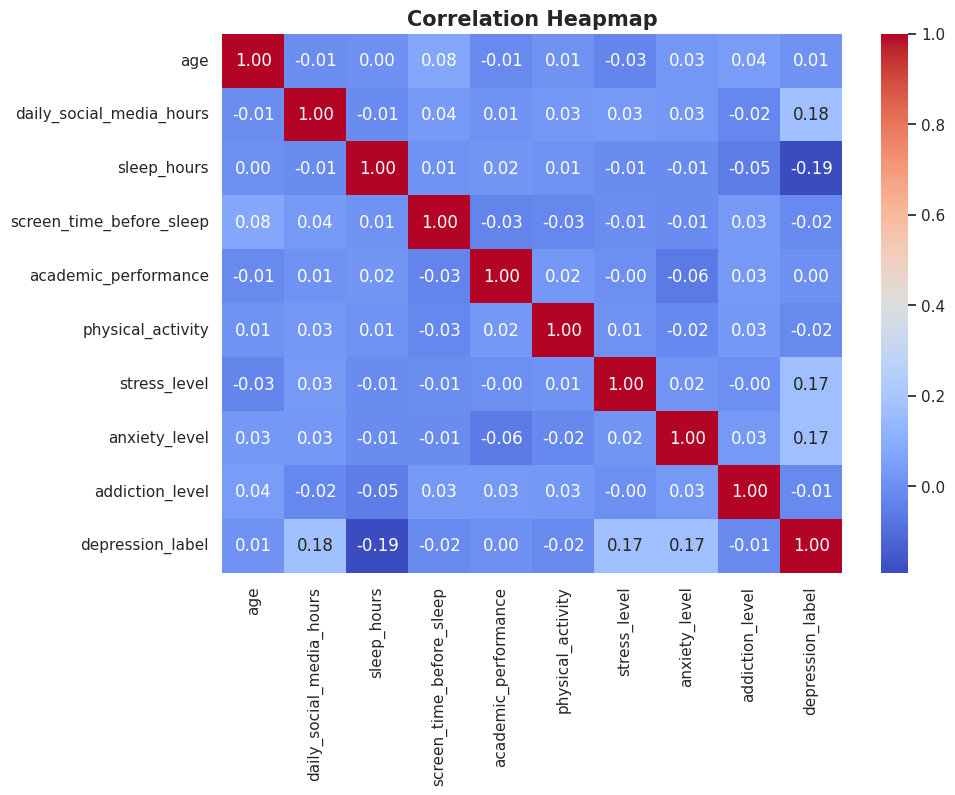

In [20]:
plt.figure(figsize=(10,7))
sns.heatmap(
    mental_health.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heapmap", fontsize=15, fontweight="bold")
plt.show()

Wie in der Bivarianten Analysis schon aufgefallen, haben die Klassen: daily_social_hours, sleep_hours, stress_level, anxienty_level "hohe" Werte, was auf eine starke abhängigkeit für Depressionen hinweist

<Figure size 1800x1200 with 0 Axes>

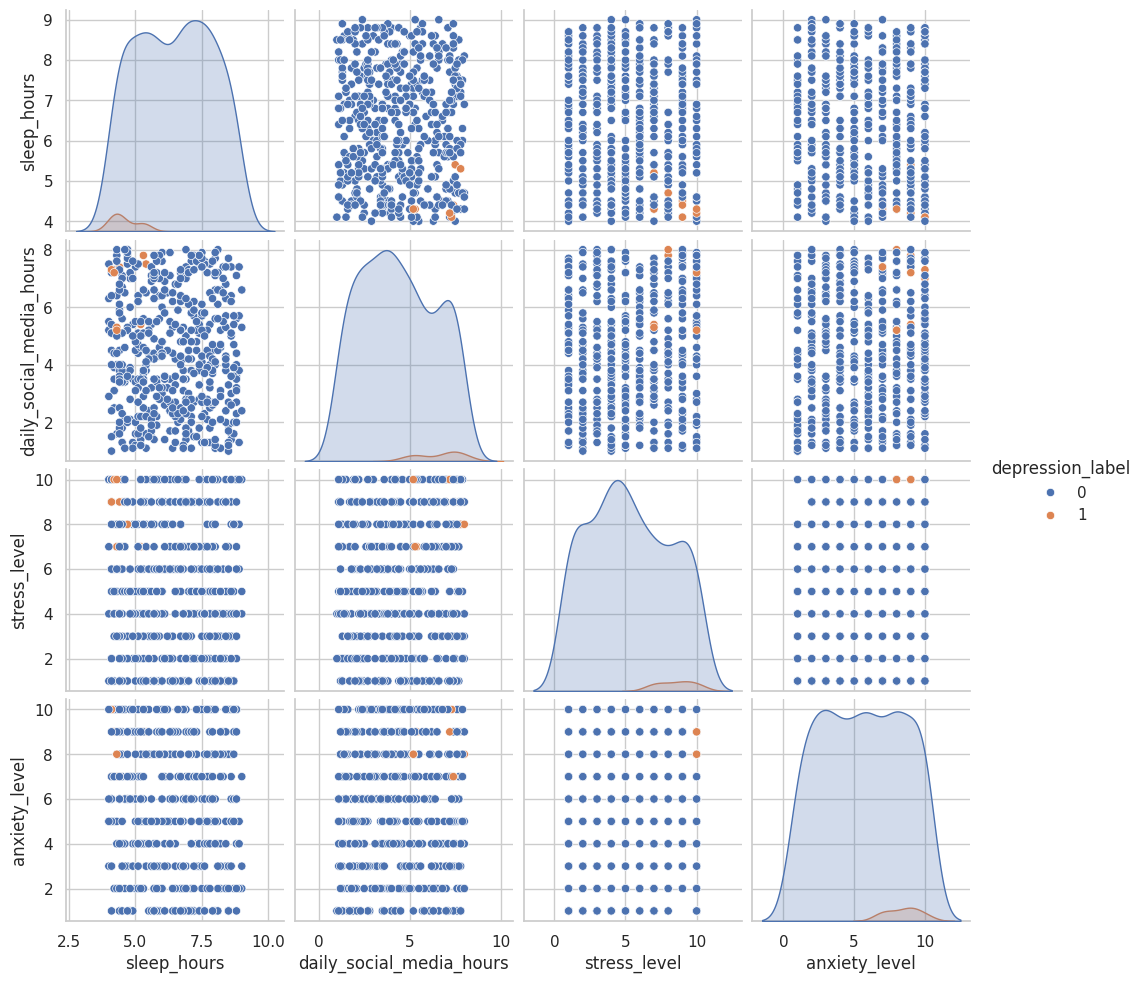

In [21]:
sample_df = mental_health.sample(500, random_state=42)

plt.figure(figsize=(18,12))

sns.pairplot(
    sample_df,
    vars=["sleep_hours", "daily_social_media_hours", "stress_level", "anxiety_level"],
    hue="depression_label"
)

plt.show()